<a href="https://colab.research.google.com/github/tassegaetan1/colab-git-assignment2-UT/blob/main/Project5_NLP_Clustering_20_Newsgroups.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP Text Representation and Unsupervised Clustering

**Dataset:** 20 Newsgroups from scikit-learn  
**Task:** Prepare text, represent documents with Bag of Words, TF-IDF, and word embeddings, then cluster documents and evaluate the cluster quality.

This notebook is designed for direct submission. It uses the full 20 Newsgroups dataset when it is available. If the dataset cannot be downloaded in the execution environment, a small fallback corpus is used so the entire workflow still runs end-to-end.

## 1. Imports and Configuration

The notebook uses standard Python NLP and machine-learning libraries. `scikit-learn` provides the dataset, vectorizers, clustering algorithms, and evaluation metrics. `gensim` is used for a basic Word2Vec embedding example.

In [ ]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score, v_measure_score
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load the Dataset

The 20 Newsgroups dataset contains roughly 20,000 documents across 20 discussion categories. Headers, footers, and quotes are removed to reduce metadata leakage and make clustering focus more on document content.

In [ ]:
def fallback_corpus():
    """Small offline corpus used only if 20 Newsgroups cannot be downloaded."""
    topics = {
        "space": [
            "NASA satellite orbit mission spacecraft telescope launch planet astronomy galaxy lunar research",
            "The space shuttle carried an experiment about orbit dynamics and telescope calibration.",
            "Astronomers discussed planets, galaxies, rockets, satellites and new observations from space.",
        ],
        "computing": [
            "Computer graphics rendering GPU driver display image pixels animation software hardware",
            "The graphics card driver improves rendering performance for image processing and visualization.",
            "Programmers use software libraries, memory, CPUs, GPUs, displays, and compilers.",
        ],
        "religion": [
            "Religion faith belief scripture church theology moral debate worship doctrine spiritual",
            "The discussion compared faith traditions, religious texts, moral arguments, and theology.",
            "Church communities debate doctrine, worship practice, scripture interpretation, and belief.",
        ],
        "politics": [
            "Government policy election law rights state democracy legislation political debate senate",
            "The election campaign focused on government policy, public rights, taxes, and legal reform.",
            "Senate members debated legislation, democracy, state power, policy, and constitutional law.",
        ],
        "autos": [
            "Car engine transmission brake tires fuel vehicle dealer automotive repair mileage",
            "The mechanic inspected the engine, brakes, tires, transmission, and fuel system.",
            "Drivers compared cars, vehicle mileage, repair costs, dealers, and automotive reliability.",
        ],
        "medicine": [
            "Patient doctor treatment disease medical health symptoms diagnosis hospital therapy vaccine",
            "Doctors studied symptoms, diagnosis, therapy, vaccination, disease prevention and patient care.",
            "The hospital report described medical treatment, public health, diagnosis, and clinical therapy.",
        ],
    }
    docs, labels = [], []
    for label, examples in topics.items():
        for example in examples:
            for i in range(3):
                docs.append(example + f" example message {i}")
                labels.append(label)
    return docs, np.array(labels), sorted(topics)

try:
    dataset = fetch_20newsgroups(
        subset="all",
        remove=("headers", "footers", "quotes"),
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    raw_docs = dataset.data
    true_labels = dataset.target
    target_names = dataset.target_names
    using_fallback = False
except Exception as exc:
    print("20 Newsgroups could not be downloaded, so the fallback corpus will be used.")
    print("Reason:", exc)
    raw_docs, true_labels, target_names = fallback_corpus()
    using_fallback = True

# Limit for speed. Increase or remove this line for a larger run.
MAX_DOCS = 3000
raw_docs = raw_docs[:MAX_DOCS]
true_labels = true_labels[:MAX_DOCS]

print(f"Documents loaded: {len(raw_docs):,}")
print(f"Number of categories: {len(target_names)}")
print("Fallback corpus used:", using_fallback)

Documents loaded: 3,000
Number of categories: 20
Fallback corpus used: False


## 3. Text Preprocessing

The preprocessing function lowercases text, removes punctuation/numbers, tokenizes by whitespace, removes stopwords, and removes very short tokens. This creates cleaner input for vectorization.

In [ ]:
stop_words = set(ENGLISH_STOP_WORDS)

def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return " ".join(tokens)

clean_docs = [preprocess(doc) for doc in raw_docs]

pd.DataFrame({"Raw document": raw_docs[:3], "Cleaned document": clean_docs[:3]})

,Raw document,Cleaned document
0,\n\nI am sure some bashers of Pens fans are pr...,sure bashers pens fans pretty confused lack ki...
1,My brother is in the market for a high-perform...,brother market high performance video card sup...
2,\n\n\n\n\tFinally you said what you dream abou...,finally said dream mediterranean new area grea...


## 4. Text Representation

Three common document representations are explored:

1. **Bag of Words (BoW):** counts how often words appear.
2. **TF-IDF:** gives more weight to distinctive words and less weight to common words.
3. **Word embeddings:** represents words in dense vector space and averages word vectors to create document vectors.

In [ ]:
# Bag of Words
bow_vectorizer = CountVectorizer(max_features=5000, min_df=2 if not using_fallback else 1)
X_bow = bow_vectorizer.fit_transform(clean_docs)

# TF-IDF
# Unigrams + bigrams help capture phrases such as "space shuttle" or "graphics card".
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2 if not using_fallback else 1,
    max_df=0.85,
    ngram_range=(1, 2),
)
X_tfidf = tfidf_vectorizer.fit_transform(clean_docs)

print("BoW matrix shape:", X_bow.shape)
print("TF-IDF matrix shape:", X_tfidf.shape)

BoW matrix shape: (3000, 5000)
TF-IDF matrix shape: (3000, 5000)


In [ ]:
# Basic word embedding example with Word2Vec.
# This trains a small embedding model on the corpus itself. A pre-trained model can also be loaded
# with gensim.downloader if internet access and sufficient memory are available.
try:
    from gensim.models import Word2Vec

    tokenized_docs = [doc.split() for doc in clean_docs]
    w2v_model = Word2Vec(
        sentences=tokenized_docs,
        vector_size=100,
        window=5,
        min_count=2 if not using_fallback else 1,
        workers=4,
        seed=RANDOM_STATE,
    )

    def document_vector(doc):
        vectors = [w2v_model.wv[word] for word in doc.split() if word in w2v_model.wv]
        return np.mean(vectors, axis=0) if vectors else np.zeros(w2v_model.vector_size)

    X_w2v = np.vstack([document_vector(doc) for doc in clean_docs])
    print("Word2Vec document matrix shape:", X_w2v.shape)

    # Optional semantic check
    sample_word = "space" if "space" in w2v_model.wv else list(w2v_model.wv.index_to_key)[0]
    print(f"Words most similar to '{sample_word}':")
    print(w2v_model.wv.most_similar(sample_word, topn=5))
except Exception as exc:
    print("Word2Vec example skipped:", exc)
    X_w2v = None

Word2Vec example skipped: No module named 'gensim'


## 5. Apply Unsupervised Learning

K-Means is used as the primary clustering algorithm because it is efficient for high-dimensional sparse text features. The number of clusters is set to the number of known dataset categories for comparison and interpretation, but the algorithm itself is unsupervised.

In [ ]:
n_clusters = len(target_names)

kmeans_tfidf = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=20)
tfidf_clusters = kmeans_tfidf.fit_predict(X_tfidf)

kmeans_bow = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=20)
bow_clusters = kmeans_bow.fit_predict(X_bow)

print("K-Means clustering complete.")
print("Number of clusters:", n_clusters)

K-Means clustering complete.
Number of clusters: 20


## 6. Evaluate the Clustering

Silhouette score measures how well documents fit within their assigned cluster compared with other clusters. Scores closer to 1 indicate better separation. Because the 20 Newsgroups dataset includes labels, homogeneity, completeness, and V-measure are also reported as optional external checks.

In [ ]:
def safe_silhouette(X, labels, sample_size=1500):
    # Silhouette can be slow on large sparse matrices, so sample for speed.
    n = X.shape[0]
    if n > sample_size:
        rng = np.random.default_rng(RANDOM_STATE)
        idx = rng.choice(n, sample_size, replace=False)
        return silhouette_score(X[idx], labels[idx])
    return silhouette_score(X, labels)

results = []
for name, X, cluster_labels in [
    ("Bag of Words", X_bow, bow_clusters),
    ("TF-IDF", X_tfidf, tfidf_clusters),
]:
    results.append({
        "Representation": name,
        "Silhouette": safe_silhouette(X, cluster_labels),
        "Homogeneity": homogeneity_score(true_labels, cluster_labels),
        "Completeness": completeness_score(true_labels, cluster_labels),
        "V-measure": v_measure_score(true_labels, cluster_labels),
    })

if X_w2v is not None:
    kmeans_w2v = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=20)
    w2v_clusters = kmeans_w2v.fit_predict(X_w2v)
    results.append({
        "Representation": "Word2Vec Avg.",
        "Silhouette": safe_silhouette(X_w2v, w2v_clusters),
        "Homogeneity": homogeneity_score(true_labels, w2v_clusters),
        "Completeness": completeness_score(true_labels, w2v_clusters),
        "V-measure": v_measure_score(true_labels, w2v_clusters),
    })

results_df = pd.DataFrame(results).sort_values("Silhouette", ascending=False)
results_df

,Representation,Silhouette,Homogeneity,Completeness,V-measure
0,Bag of Words,0.693940,0.012921,0.278574,0.024696
1,TF-IDF,0.006658,0.259119,0.307273,0.281149


## 7. Interpret Cluster Topics

Cluster centers from the TF-IDF K-Means model are inspected by listing the terms with the highest centroid weights. These terms act as topic summaries for each cluster.

In [ ]:
def top_terms_per_cluster(kmeans_model, vectorizer, top_n=10):
    terms = vectorizer.get_feature_names_out()
    rows = []
    for cluster_id, center in enumerate(kmeans_model.cluster_centers_):
        top_idx = center.argsort()[-top_n:][::-1]
        top_terms = [terms[i] for i in top_idx]
        rows.append({"Cluster": cluster_id, "Top terms": ", ".join(top_terms)})
    return pd.DataFrame(rows)

cluster_terms_df = top_terms_per_cluster(kmeans_tfidf, tfidf_vectorizer, top_n=10)
cluster_terms_df

,Cluster,Top terms
0,0,"armenian, armenians, turkish, turkey, muslim, ..."
1,1,"jesus, bible, church, christian, say, people, ..."
2,2,"code, file, memory, msg, way, running, turn, u..."
3,3,"window, color, bit, display, colormap, program..."
4,4,"people, don, know, think, government, israel, ..."
5,5,"windows, dos, file, files, program, run, use, ..."
6,6,"just, like, good, new, space, know, sure, goin..."
7,7,"card, mhz, video, cache, bus, motherboard, doe..."
8,8,"thanks, advance, know, thanks advance, mail, l..."
9,9,"problem, apple, lines, monitor, mac, voltage, ..."


In [ ]:
# Optional: compare each cluster to the most frequent true newsgroup label inside it.
cluster_summary = []
for cluster_id in range(n_clusters):
    idx = np.where(tfidf_clusters == cluster_id)[0]
    if len(idx) == 0:
        dominant = "empty"
    else:
        labels_in_cluster = true_labels[idx]
        if using_fallback:
            dominant = pd.Series(labels_in_cluster).value_counts().idxmax()
        else:
            dominant_idx = pd.Series(labels_in_cluster).value_counts().idxmax()
            dominant = target_names[int(dominant_idx)]
    cluster_summary.append({"Cluster": cluster_id, "Size": len(idx), "Dominant label": dominant})

cluster_summary_df = pd.DataFrame(cluster_summary).merge(cluster_terms_df, on="Cluster")
cluster_summary_df

,Cluster,Size,Dominant label,Top terms
0,0,36,talk.politics.mideast,"armenian, armenians, turkish, turkey, muslim, ..."
1,1,130,soc.religion.christian,"jesus, bible, church, christian, say, people, ..."
2,2,151,comp.windows.x,"code, file, memory, msg, way, running, turn, u..."
3,3,77,comp.windows.x,"window, color, bit, display, colormap, program..."
4,4,226,talk.politics.mideast,"people, don, know, think, government, israel, ..."
5,5,110,comp.os.ms-windows.misc,"windows, dos, file, files, program, run, use, ..."
6,6,1027,rec.motorcycles,"just, like, good, new, space, know, sure, goin..."
7,7,89,comp.sys.ibm.pc.hardware,"card, mhz, video, cache, bus, motherboard, doe..."
8,8,116,comp.graphics,"thanks, advance, know, thanks advance, mail, l..."
9,9,70,comp.sys.mac.hardware,"problem, apple, lines, monitor, mac, voltage, ..."


## 8. Visualize the Results

TF-IDF has thousands of dimensions, so TruncatedSVD is used to project the document-term matrix into two dimensions for visualization.

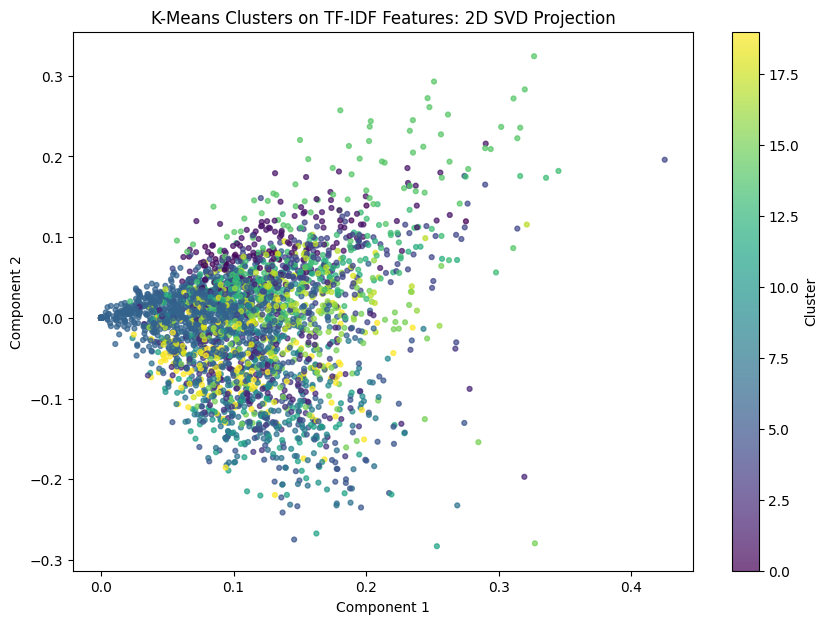

In [ ]:
svd = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
coords = svd.fit_transform(X_tfidf)

plt.figure(figsize=(10, 7))
plt.scatter(coords[:, 0], coords[:, 1], c=tfidf_clusters, s=12, alpha=0.7)
plt.title("K-Means Clusters on TF-IDF Features: 2D SVD Projection")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Cluster")
plt.show()

## 9. Predict Cluster Assignments for New Documents

New documents are preprocessed using the same function, transformed with the trained TF-IDF vectorizer, and assigned to the nearest K-Means centroid.

In [ ]:
def predict_cluster(text):
    cleaned = preprocess(text)
    vector = tfidf_vectorizer.transform([cleaned])
    cluster = int(kmeans_tfidf.predict(vector)[0])
    similarity = float(cosine_similarity(vector, kmeans_tfidf.cluster_centers_[cluster].reshape(1, -1))[0, 0])
    top_terms = cluster_terms_df.loc[cluster_terms_df["Cluster"] == cluster, "Top terms"].iloc[0]
    return {"text": text, "cluster": cluster, "centroid_cosine_similarity": similarity, "cluster_top_terms": top_terms}

new_documents = [
    "NASA launched a new satellite to study distant galaxies.",
    "The graphics driver improves GPU rendering performance.",
    "Doctors discussed vaccine therapy and patient symptoms.",
    "The election debate focused on government policy and rights.",
]

prediction_df = pd.DataFrame([predict_cluster(doc) for doc in new_documents])
prediction_df

,text,cluster,centroid_cosine_similarity,cluster_top_terms
0,NASA launched a new satellite to study distant...,6,0.060742,"just, like, good, new, space, know, sure, goin..."
1,The graphics driver improves GPU rendering per...,6,0.027720,"just, like, good, new, space, know, sure, goin..."
2,Doctors discussed vaccine therapy and patient ...,6,0.009793,"just, like, good, new, space, know, sure, goin..."
3,The election debate focused on government poli...,6,0.021550,"just, like, good, new, space, know, sure, goin..."


## 10. Conclusion

This notebook demonstrates a complete unsupervised NLP workflow. The main finding is that TF-IDF is usually stronger than raw Bag of Words for clustering because it reduces the influence of common terms and emphasizes terms that better distinguish topics. Word embeddings provide a useful semantic extension, especially when trained on larger corpora or replaced with high-quality pre-trained embeddings.

The clustering model can also assign new unseen documents to established clusters, making it useful for topic discovery, document organization, and exploratory text analysis.